# Process variables analysis

This notebook presents a study of operational limits in the processes variables to prevent failures.

TO-DOs

- Plotar as variáveis de processo em uma série temporal marcando o tipo de falha relevante para a variável e indicando os possíveis limites de operação normal
- Para os casos onde os limites são definidos por mais de uma variável testar duas estratégias: criar uma nova feature multiplicando as variáveis para combiná-las e indicar os limites no gráfico dessa nova variável e fazer um plot de cada variável em um eixo delimitando os limites usando um retângulo
- Verificar como estão distribuídos os tipos de produto no histórico (aleatório ou campanhas) plotando os pontos em uma linha do tempo colorida conforme o tipo de produto e depois usando o método das matrizes de transição para provar a aleatoriedade da distribuição de produtos.

In [60]:
# Imports
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from local_settings import postgres_url as url
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [61]:
# Load 'milling_pdm_celsius' dataset to a pandas dataframe
url = f"postgresql+psycopg2://{url['pguser']}:{url['pgpassword']}@{url['pghost']}/{url['pgdb']}"
engine = create_engine(url)
df = pd.read_sql(f"SELECT * FROM milling_pdm_celsius",con=engine, index_col="register_id")
df

,product_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
register_id,,,,,,,,,,,,,
1,M14860,M,24.950006,35.450006,1551.0,42.8,0,False,False,False,False,False,False
2,L47181,L,25.050012,35.550012,1408.0,46.3,3,False,False,False,False,False,False
3,L47182,L,24.950006,35.350000,1498.0,49.4,5,False,False,False,False,False,False
4,L47183,L,25.050012,35.450006,1433.0,39.5,7,False,False,False,False,False,False
5,L47184,L,25.050012,35.550012,1408.0,40.0,9,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,M24855,M,25.649988,35.249994,1604.0,29.5,14,False,False,False,False,False,False
9997,H39410,H,25.749994,35.249994,1632.0,31.8,17,False,False,False,False,False,False
9998,M24857,M,25.850000,35.450006,1645.0,33.4,22,False,False,False,False,False,False


In [62]:
# Load 'failure_data_unpivoted' dataset to a pandas dataframe
df_failure_mode = pd.read_sql(f"SELECT * FROM failure_data_unpivoted",con=engine, index_col="register_id")
df_failure_mode

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,machine_failure,status
register_id,,,,,,,
1,M,24.950006,35.450006,1551.0,42.8,False,NORMAL
2,L,25.050012,35.550012,1408.0,46.3,False,NORMAL
3,L,24.950006,35.350000,1498.0,49.4,False,NORMAL
4,L,25.050012,35.450006,1433.0,39.5,False,NORMAL
5,L,25.050012,35.550012,1408.0,40.0,False,NORMAL
...,...,...,...,...,...,...,...
9996,M,25.649988,35.249994,1604.0,29.5,False,NORMAL
9997,H,25.749994,35.249994,1632.0,31.8,False,NORMAL
9998,M,25.850000,35.450006,1645.0,33.4,False,NORMAL


In [63]:
# Add new features

## Mechanical Power in kW
df["rotational_speed_rps"] = 2*np.pi*df["rotational_speed_rpm"] / 60 # Convert rotational speed to rad/s
df["mech_power_kwatts"] = (df["rotational_speed_rps"] * df["torque_nm"])/1000 # Create a column for mechanical power in kW
df_failure_mode["mech_power_kwatts"] = df["mech_power_kwatts"]

## Temperature difference in °C
df["delta_temperature_celsius"] = df["process_temperature_celsius"] - df["air_temperature_celsius"]
df_failure_mode["delta_temperature_celsius"] = df["delta_temperature_celsius"]

## Time-series plot of process variables

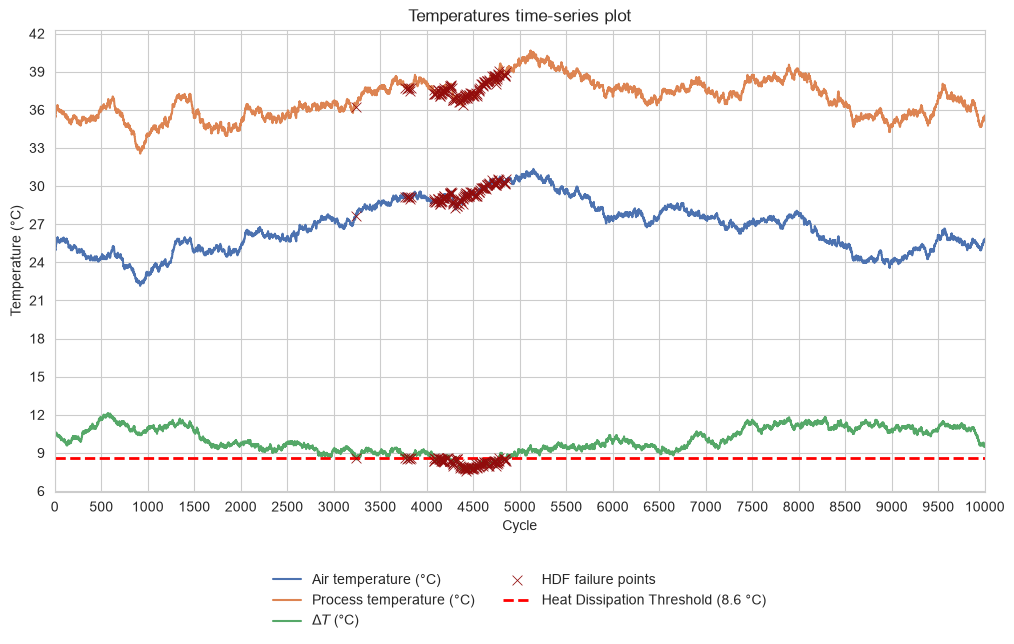

In [74]:
# Time-series plot of air_temperature_celsius, process_temperature_celsius and temperature difference

## Create a temperature dataframe with only temperature and failure columns
df_temp = df_failure_mode[["air_temperature_celsius", "process_temperature_celsius", "delta_temperature_celsius"]]
rename_dict = {"air_temperature_celsius": "Air temperature (°C)",
               "process_temperature_celsius": "Process temperature (°C)",
               "delta_temperature_celsius": r"$\Delta T$ (°C)"}

## Create failure mode dataframe with only temperature columns and filtered for HDF failures status
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = pd.concat([df_hdf["air_temperature_celsius"], df_hdf["process_temperature_celsius"], df_hdf["delta_temperature_celsius"]], join='outer')

## Calculate threshold on temperature difference for HDF
temp_thresh = max(df_failure_mode[df_failure_mode["status"]=="HDF"]["delta_temperature_celsius"])

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.lineplot(data=df_temp.rename(columns=rename_dict),
             dashes=False,
             palette="deep")

## Plot failures
sns.scatterplot(data=df_hdf,
                marker="x",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

## Plot variable limits
plt.axhline(
    y=temp_thresh, 
    color='red', 
    linestyle='--',
    linewidth=2, 
    label=f'Heat Dissipation Threshold ({temp_thresh:.1f} °C)'
)
print("")

## Plot settings
plt.xlim(left=0, right=10000)
plt.xticks(np.arange(0,10001,500))
plt.yticks(np.arange(6,43,3))
plt.title("Temperatures time-series plot")
plt.xlabel("Cycle")
plt.ylabel("Temperature (°C)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

In [83]:
# If the threshold is used as an alarm, how many false positives it would give?
total_points = df_failure_mode[(df_failure_mode["delta_temperature_celsius"]<=temp_thresh)].shape[0]
false_positives = df_failure_mode[(df_failure_mode["delta_temperature_celsius"]<=temp_thresh) & (df_failure_mode["status"]!="HDF")].shape[0]
print(f"The alarm should ring at {total_points} points, giving a total of {false_positives} false positives ({false_positives/total_points*100:.0f}%)")

The alarm should ring at 814 points, giving a total of 699 false positives (86%)


- Both air and process temperatures exhibit a drifting behavior rather than a steady state. This raises two physical hypotheses: either the thermal sensors are degrading over time, or the machine is transitioning between distinct operating regimes. Since manufacturing plants often run products of the same quality in continuous batches (campaigns), our next step is to investigate the production sequence to see if these temperature shifts align with product changeovers.
- Plotting the heat dissipation failure points along with the temperatures we can identify a lower limit in temperature difference at 8.6°C that triggers this failure mode. However, using this trigger as an alarm threshold would generate a total of 699 false positives which corresponds to 86% of the alerts, indicating that another variable should be involved in the heat dissipation failure trigger.
- Furthermore, the discovery of a crisp, well-defined mathematical threshold for HDF failures at strictly $8.6^\circ\text{C}$ strongly discards the hypothesis of sensor drift, confirming that the sensors are calibrated and the thermal variance is indeed caused by actual operational shifts

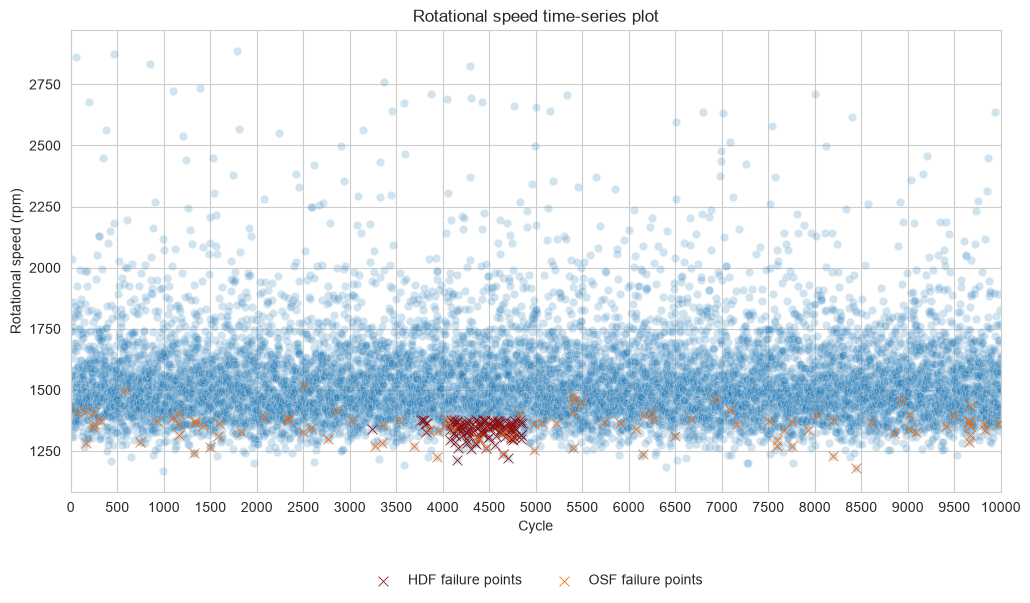

In [94]:
# Time-series plot of rotational_speed_rpm

## Create a dataframe with only rotational speed and failure columns
df_speed = df_failure_mode["rotational_speed_rpm"]
rename_dict = {"rotational_speed_rpm": "Rotational speed (rpm)"}

## Create failure mode dataframe with HDF points
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = df_hdf["rotational_speed_rpm"]

## Create failure mode dataframe with OSF points
df_osf = df_failure_mode[df_failure_mode["status"]=="OSF"]
df_osf = df_osf["rotational_speed_rpm"]

## Calculate threshold on temperature difference for HDF
# temp_thresh = max(df_failure_mode[df_failure_mode["status"]=="HDF"]["delta_temperature_celsius"])

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# sns.lineplot(data=df_speed.rename(rename_dict))
sns.scatterplot(data=df_speed.rename(rename_dict),
                alpha=0.2)

# Plot failures
sns.scatterplot(data=df_hdf,
                marker="x",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

sns.scatterplot(data=df_osf,
                marker="x",
                s=50,
                color="#FF6600",
                zorder=5,
                label="OSF failure points");

## Plot settings
plt.xlim(left=0, right=10000)
plt.xticks(np.arange(0,10001,500))
plt.title("Rotational speed time-series plot")
plt.xlabel("Cycle")
plt.ylabel("Rotational speed (rpm)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

- The rotational speed time series exhibits high-frequency fluctuations and variance during operational cycles, which necessitated the use of a scatter plot to better visualize data density across operating ranges. This behavior is typical for CNC machines, as the motor control system constantly balances rotational speed and torque against variable friction levels induced by materials of differing hardness.

- Furthermore, time-series analysis reveals that all HDF failure points occur below 1380 RPM, and all OSF failure points occur below 1515 RPM. However, since a large volume of non-failure data points also exists below these thresholds, these speed limits alone are insufficient for predictive failure modeling. Given these results, a multivariate approach (combining speed with torque or temperature) is required to achieve meaningful failure prediction.

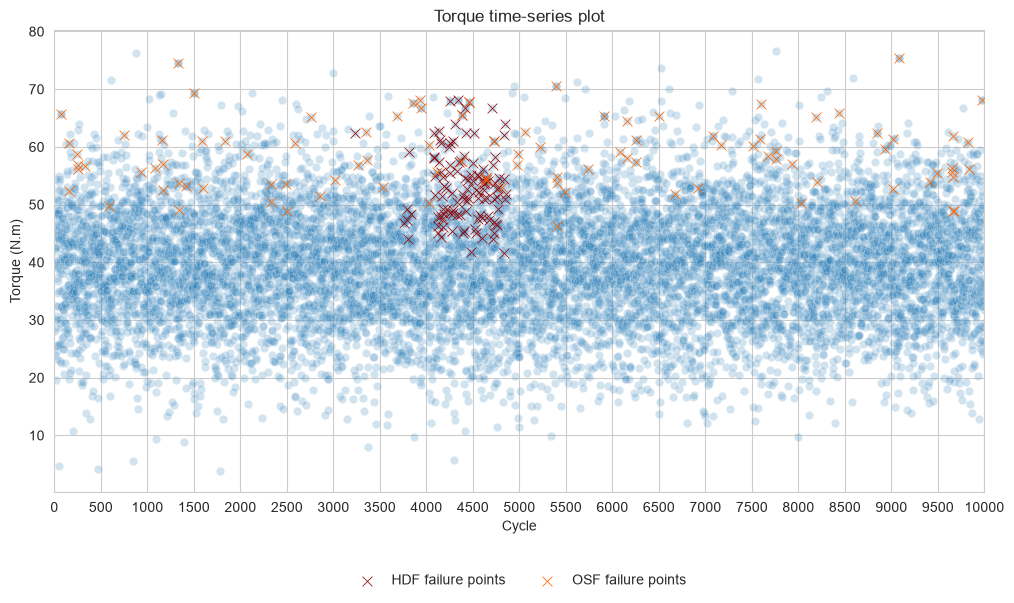

In [102]:
# Time-series plot of torque_nm

## Create a dataframe with only torque and failure columns
df_torque = df_failure_mode["torque_nm"]
rename_dict = {"torque_nm": "Torque (N.m)"}

## Create failure mode dataframe with HDF points
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = df_hdf["torque_nm"]

## Create failure mode dataframe with OSF points
df_osf = df_failure_mode[df_failure_mode["status"]=="OSF"]
df_osf = df_osf["torque_nm"]

## Calculate threshold on temperature difference for HDF
# temp_thresh = max(df_failure_mode[df_failure_mode["status"]=="HDF"]["delta_temperature_celsius"])

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# sns.lineplot(data=df_torque.rename(rename_dict))
sns.scatterplot(data=df_torque.rename(rename_dict),
                alpha=0.2)

# Plot failures
sns.scatterplot(data=df_hdf,
                marker="x",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

sns.scatterplot(data=df_osf,
                marker="x",
                s=50,
                color="#FF6600",
                zorder=5,
                label="OSF failure points");

## Plot settings
plt.xlim(left=0, right=10000)
plt.xticks(np.arange(0,10001,500))
plt.title("Torque time-series plot")
plt.xlabel("Cycle")
plt.ylabel("Torque (N.m)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

- The same behaviour of high-frequency fluctuations and variance is observed for the torque signal for the same reason used to explain the rotational speed behaviour.

- Furthermore, time-series analysis reveals that all HDF failure points occur above 41.6 N.m, and all OSF failure points occur above 46.3 N.m. However, as observed for the rotational speed, since a large volume of non-failure data points also exists above these thresholds, these torque limits alone are insufficient for predictive failure modeling.

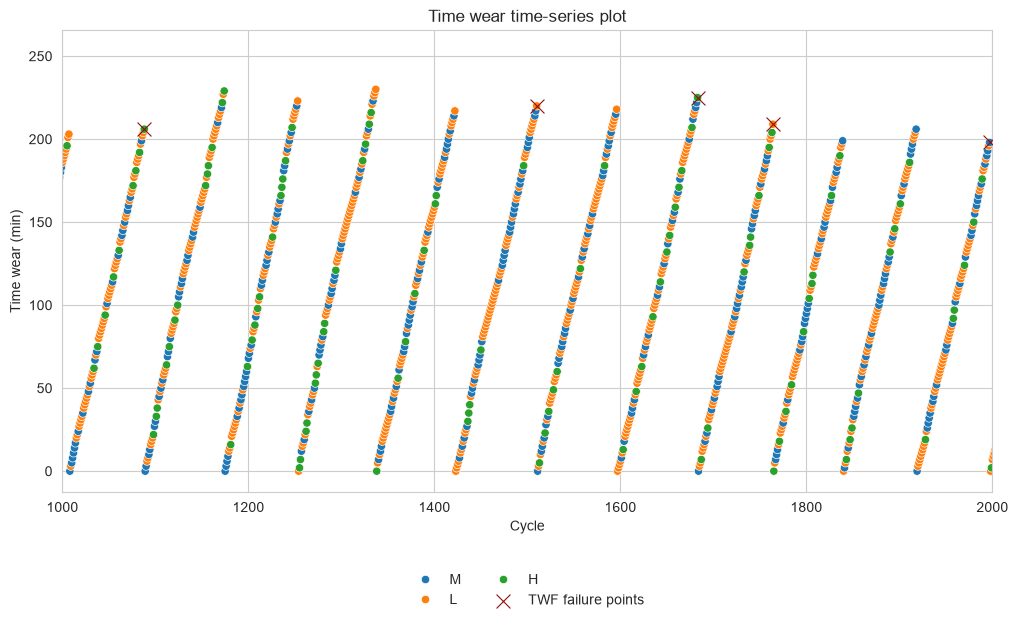

In [133]:
# Time-series plot of tool_wear_min

## Create a dataframe with only tool wear and failure columns
df_wear = df["tool_wear_min"]
rename_dict = {"tool_wear_min": "Tool wear (min)"}

## Create failure mode dataframe with TWF points
df_twf = df[df["tool_wear_failure"]]
df_twf = df_twf["tool_wear_min"]

## Create failure mode dataframe with OSF points
# df_osf = df_failure_mode[df_failure_mode["status"]=="OSF"]
# df_osf = df_osf["tool_wear_min"]

## Calculate threshold on temperature difference for HDF
# temp_thresh = max(df_failure_mode[df_failure_mode["status"]=="HDF"]["delta_temperature_celsius"])

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.scatterplot(x="register_id",
                y="tool_wear_min",
                data=df,
                hue="product_type")

## Plot failures
sns.scatterplot(data=df_twf,
                marker="x",
                s=100,
                color="#920C0C",
                zorder=5,
                label="TWF failure points")

# sns.scatterplot(data=df_osf,
#                 marker="x",
#                 s=50,
#                 color="#FF6600",
#                 zorder=5,
#                 label="OSF failure points");

## Plot settings
plt.xlim(left=1000, right=2000)
#plt.xticks(np.arange(0,10001,500))
plt.title("Time wear time-series plot")
plt.xlabel("Cycle")
plt.ylabel("Time wear (min)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

## Timeline of machined products by quality

In [7]:
# Criamos uma coluna que olha qual é o "próximo" produto usinado
df['next_type'] = df['product_type'].shift(-1)

# Calculamos a Matriz de Transição (Probabilidade de ir do Produto X para o Y)
# normalize='index' transforma a contagem em porcentagem por linha
# matriz_transicao = pd.crosstab(df['product_type'], df['next_type'], normalize='index') * 100
matriz_transicao = pd.crosstab(df['product_type'], df['next_type'])

print(matriz_transicao.round(1))

next_type       H     L     M
product_type                 
H             109   591   303
L             596  3619  1785
M             298  1790   908


In [8]:
df_failure_mode = pd.read_sql(f"SELECT * FROM failure_data_unpivoted",con=engine, index_col="register_id")
df_failure_mode.reset_index(inplace=True)
df_failure_mode

,register_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,machine_failure,status
0,1,M,24.950006,35.450006,1551.0,42.8,False,NORMAL
1,2,L,25.050012,35.550012,1408.0,46.3,False,NORMAL
2,3,L,24.950006,35.350000,1498.0,49.4,False,NORMAL
3,4,L,25.050012,35.450006,1433.0,39.5,False,NORMAL
4,5,L,25.050012,35.550012,1408.0,40.0,False,NORMAL
...,...,...,...,...,...,...,...,...
10011,9996,M,25.649988,35.249994,1604.0,29.5,False,NORMAL
10012,9997,H,25.749994,35.249994,1632.0,31.8,False,NORMAL
10013,9998,M,25.850000,35.450006,1645.0,33.4,False,NORMAL
10014,9999,H,25.850000,35.550012,1408.0,48.5,False,NORMAL


In [9]:
import pandas as pd
import numpy as np

# A mágica que você descreveu:
tabela_diagnostico_termico = pd.crosstab(
    index=df_failure_mode['product_type'],                # Linhas: Tipo de Produto (L, M, H)
    columns=df_failure_mode['status'],        # Colunas: Qual foi a falha (Normal, HDF, PWF, TWF...)
    values=df_failure_mode['process_temperature_celsius'], # Recheio: A Temperatura do Processo
    aggfunc='mean'                   # Agregação: Média
).round(1) # Arredondando para 1 casa decimal para ficar bonito no relatório

# Adicionando um mapa de calor na própria tabela (Fica lindo no Jupyter!)
tabela_diagnostico_termico.style.background_gradient(cmap='YlOrRd')

status,HDF,NORMAL,OSF,PWF,RDF,TWF
product_type,,,,,,
H,37.800000,36.800000,38.200000,37.000000,37.500000,36.300000
L,37.700000,36.900000,36.900000,36.800000,38.000000,37.000000
M,37.500000,36.900000,37.200000,36.800000,35.600000,37.300000


## Conclusion